# 03 - 线性回归实战

## 学习目标
- 理解线性回归的数学原理
- 使用 scikit-learn 实现线性回归
- 掌握完整的 ML 工作流：数据 → 预处理 → 训练 → 评估 → 可视化

## 数据集
加州房价数据集 (California Housing)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. 数据加载与探索

In [2]:
# 加载数据
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

print(f'数据集形状: {X.shape}')
print(f'特征列: {list(X.columns)}')
print(f'\n目标变量 (房价中位数, 单位: 十万美元):')
print(pd.Series(y).describe())

数据集形状: (20640, 8)
特征列: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

目标变量 (房价中位数, 单位: 十万美元):
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
dtype: float64


In [3]:
# 数据概览
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


C:\Users\210218672\AppData\Local\Temp\ipykernel_26672\3152116455.py:11: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\210218672\AppData\Local\Temp\ipykernel_26672\3152116455.py:11: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\210218672\AppData\Local\Temp\ipykernel_26672\3152116455.py:11: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\210218672\AppData\Local\Temp\ipykernel_26672\3152116455.py:11: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\210218672\Desktop\AIEngineer\src\ml-library-practice\venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\

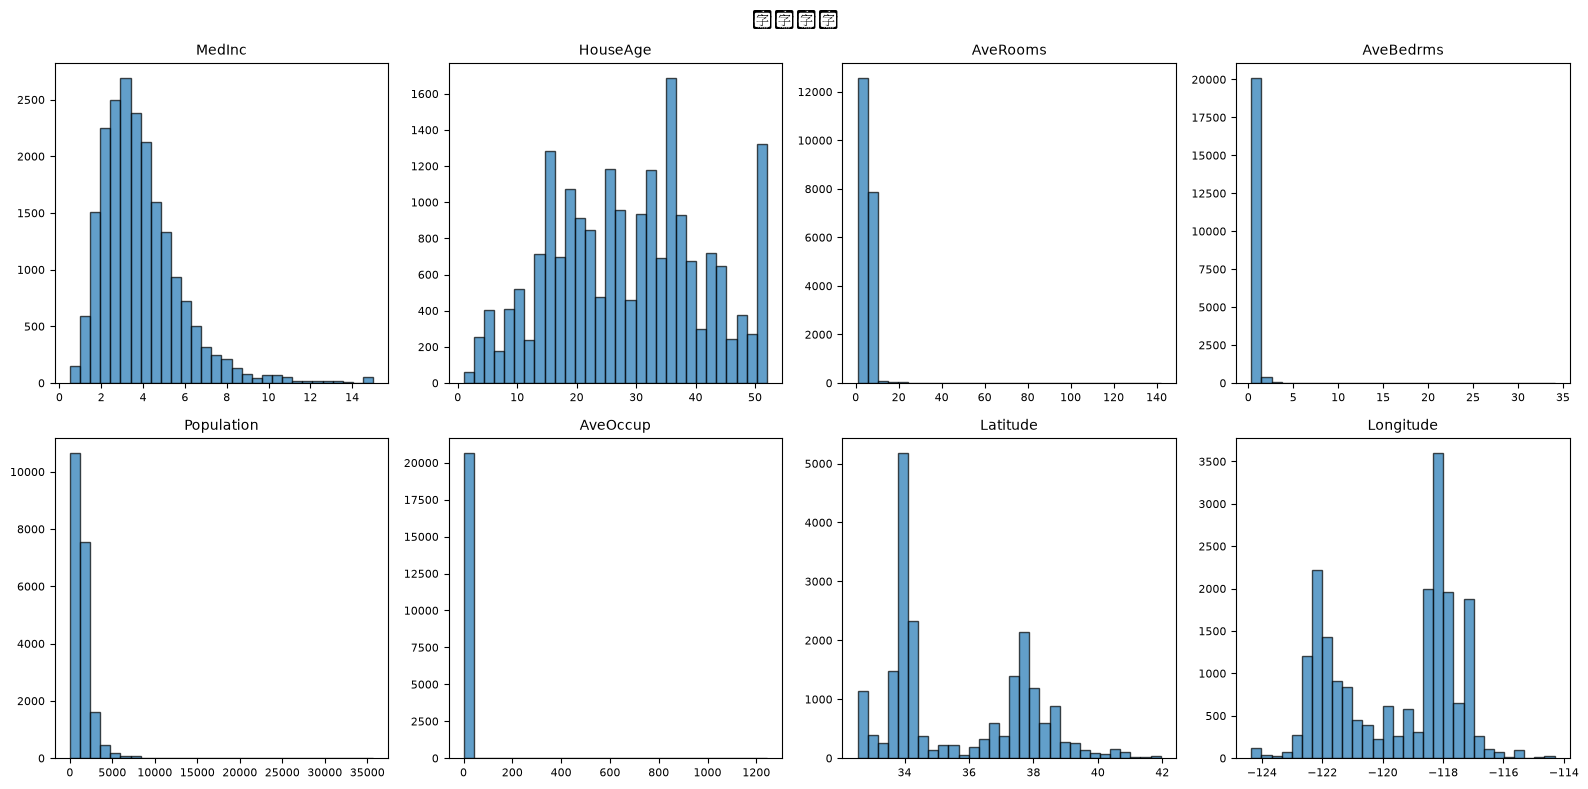

In [4]:
# 特征分布
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

plt.suptitle('特征分布', fontsize=14)
plt.tight_layout()
plt.show()

## 2. 数据预处理

In [5]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'训练集: {X_train.shape}')
print(f'测试集: {X_test.shape}')

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # 注意：只用 transform！

print(f'\n标准化后训练集均值: {X_train_scaled.mean(axis=0).round(4)}')
print(f'标准化后训练集标准差: {X_train_scaled.std(axis=0).round(4)}')

训练集: (16512, 8)
测试集: (4128, 8)

标准化后训练集均值: [-0. -0.  0. -0.  0.  0.  0.  0.]
标准化后训练集标准差: [1. 1. 1. 1. 1. 1. 1. 1.]


## 3. 模型训练

In [6]:
# 创建并训练线性回归模型
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 查看模型参数
print('模型系数 (标准化后):')
print('-' * 40)
for feature, coef in sorted(zip(california.feature_names, model.coef_), key=lambda x: abs(x[1]), reverse=True):
    bar = '█' * int(abs(coef) * 5)
    print(f'  {feature:15s}: {coef:+.4f}  {bar}')
print(f'  {"截距":15s}: {model.intercept_:+.4f}')

模型系数 (标准化后):
----------------------------------------
  Latitude       : -0.8969  ████
  Longitude      : -0.8698  ████
  MedInc         : +0.8544  ████
  AveBedrms      : +0.3393  █
  AveRooms       : -0.2944  █
  HouseAge       : +0.1225  
  AveOccup       : -0.0408  
  Population     : -0.0023  
  截距             : +2.0719


**是的，这段代码的核心正是在训练模型**，并且在训练完成后打印出了模型学到的参数。

具体分为两大部分：**第一部分是模型的创建与训练**，**第二部分是模型参数的查看与可视化展示**。

---

### 一、训练模型的核心代码（仅 2 行）

```python
model = LinearRegression()
model.fit(X_train_scaled, y_train)
```

1. **`model = LinearRegression()`（创建模型）**：
   * 实例化一个多元线性回归估计器对象。此时模型只是一个空架子，内部还没有任何权重和参数。
2. **`model.fit(X_train_scaled, y_train)`（真正执行训练的关键行）**：
   * **`fit` 就是“训练 / 拟合”的意思**。
   * 它将**标准化的训练特征矩阵 `X_train_scaled`** 和对应的**真实房价标签 `y_train`** 输入给算法。
   * 线性回归底层会使用**最小二乘法（Ordinary Least Squares, OLS）**求解出最佳的权重参数，使得预测值与真实值之间的均方误差最小：
     $$\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$
   * 训练完成后，学到的权重保存在 `model.coef_` 中，偏置截距保存在 `model.intercept_` 中。

---

### 二、查看模型训练好的参数（后续打印代码）

训练完成后，代码通过以下逻辑将学到的数学公式可视化出来：

```python
# 查看模型参数
print('模型系数 (标准化后):')
print('-' * 40)
for feature, coef in sorted(zip(california.feature_names, model.coef_), key=lambda x: abs(x[1]), reverse=True):
    bar = '█' * int(abs(coef) * 5)
    print(f'  {feature:15s}: {coef:+.4f}  {bar}')
print(f'  {"截距":15s}: {model.intercept_:+.4f}')
```

#### 逐行解析：
* **`model.coef_`（特征系数 / 权重 $w$）**：每个特征对应的权重系数。
* **`sorted(..., key=lambda x: abs(x[1]), reverse=True)`**：
  * 将特征名称和对应的系数打包在一起，并**按照系数绝对值由大到小排序**。
  * 这里的目的是：**由于前面做了特征标准化，系数绝对值越大，代表该特征对预测房价的影响越重要**。
* **`bar = '█' * int(abs(coef) * 5)`**：
  * 用字符 `'█'` 绘制简单的水平柱状图，直观展示每个特征权重的大小。
* **`model.intercept_`（截距 $b$）**：
  * 当所有标准化特征输入为 0（即处于均值水平）时的基准预测值。

---

### 三、从运行输出看训练学到了什么

该单元格的输出结果为：
```text
模型系数 (标准化后):
----------------------------------------
  Latitude       : -0.8969  ████
  Longitude      : -0.8698  ████
  MedInc         : +0.8544  ████
  AveBedrms      : +0.3393  █
  AveRooms       : -0.2944  █
  HouseAge       : +0.1225  
  AveOccup       : -0.0408  
  Population     : -0.0023  
  截距           : +2.0719
```

从模型训练出的参数可以看出实际的业务规律：
1. **`MedInc` (收入中位数) 系数为 `+0.8544`**：正向影响非常大，该区域收入越高，房价越高。
2. **`Latitude` 与 `Longitude` 绝对值很大**：地理位置（经纬度）对加州房价具有决定性影响。
3. **`Population` 仅为 `-0.0023`**：街区总人口对房价几乎没有直接影响。

**截距（Intercept，数学上常记作 $b$ 或 $w_0$）** 可以从**数学定义**和**本项目的实际业务场景**两个层面来直观理解：

---

### 1. 数学层面的定义：起步基准值

线性回归预测公式为：
$$\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$

* **截距 $b$ 就是：当所有输入特征 $x_1, x_2, \dots, x_n$ 全部等于 0 时，模型的预测输出值**。
* 在初中数学的直线方程 $y = kx + b$ 中，它就是直线与 $y$ 轴相交的那个点（纵截距）。

---

### 2. 在本项目（加州房价预测）中的具体含义

在这个 Notebook 中，截距输出为：
$$\text{截距} = +2.0719$$

这里有一个非常关键的前提：**输入特征 $X$ 在训练前经过了 Z-score 标准化（`StandardScaler`）**。

#### 标准化后的特殊物理意义：
1. **$x=0$ 意味着什么？**
   * 在 Z-score 标准化中，$z = \frac{x - \mu}{\sigma}$。
   * 当标准化后的输入 $x = 0$ 时，代表该特征的值**正好等于原始数据的“平均水平”（$\mu$）**。
2. **截距 $2.0719$ 的业务含义：**
   * 如果一个街区的**收入、房龄、房间数、人口、经纬度等所有指标全都是加州的平均水平**（即所有 $x_i = 0$）：
   * 那么这套房子的基准预测价格就是 **2.0719（单位：十万美元）**，也就是 **约 20.72 万美元**。
   * 其他特征（如收入高于平均水平、地理位置优越等）都是在这个基准价格上进行**“加分”或“扣分”**。

> **小彩蛋验证：**
> 如果你查看前面数据探索部分计算的加州真实房价均值（`y_train.mean()`），你会发现它的均值正好就在 **2.07** 左右！
> 这正是线性回归的优雅之处：**特征标准化后，截距往往就直接等于目标变量 $y$ 的平均值**。

---

### 3. 如果没有截距会怎样？

如果强行设定模型不包含截距（$b = 0$）：
* 预测方程会变成 $\hat{y} = w_1 x_1 + \dots + w_n x_n$，这条直线/超平面被**强制必须经过坐标原点 $(0, 0)$**。
* 这样会导致直线失去自由平移的能力，为了硬凑经过原点，直线的斜率（各个特征权重 $w_i$）会被严重扭曲，导致模型拟合能力急剧下降。

---

### 总结一句话
**截距就像是房价的“底价/基准起步价”**：在所有特征都处于平均状态时，房子默认值多少钱。各个特征的系数（权重）则决定了在此基准上“涨价”或“跌价”的幅度。

## 4. 模型预测与评估

In [ ]:
# 预测
y_pred = model.predict(X_test_scaled)

# 计算评估指标
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('===== 模型评估结果 =====')
print(f'MSE  (均方误差):      {mse:.4f}')
print(f'RMSE (均方根误差):    {rmse:.4f}')
print(f'MAE  (平均绝对误差):  {mae:.4f}')
print(f'R²   (决定系数):      {r2:.4f}')
print(f'\n解读: R²={r2:.4f} 表示模型解释了 {r2*100:.1f}% 的目标变量方差')

## 5. 可视化分析

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 预测值 vs 真实值
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, c='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='完美预测')
axes[0].set_xlabel('真实值')
axes[0].set_ylabel('预测值')
axes[0].set_title('预测值 vs 真实值')
axes[0].legend()

# 残差分布
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('残差')
axes[1].set_ylabel('频数')
axes[1].set_title('残差分布')

# 特征重要性
importance = np.abs(model.coef_)
sorted_idx = np.argsort(importance)
axes[2].barh(range(len(sorted_idx)), importance[sorted_idx], color='steelblue')
axes[2].set_yticks(range(len(sorted_idx)))
axes[2].set_yticklabels(np.array(california.feature_names)[sorted_idx])
axes[2].set_xlabel('系数绝对值')
axes[2].set_title('特征重要性 (|系数|)')

plt.tight_layout()
plt.show()

## 6. 模型比较：Ridge 与 Lasso

In [ ]:
# 比较不同正则化方法
models = {
    'LinearRegression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.01)': Lasso(alpha=0.01),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('模型比较:')
print(results_df.round(4))

## 7. 保存模型

In [ ]:
import joblib
from pathlib import Path

# 创建保存目录
save_dir = Path('../../models_saved/sklearn')
save_dir.mkdir(parents=True, exist_ok=True)

# 保存模型和 scaler
final_model = LinearRegression()
final_model.fit(X_train_scaled, y_train)

joblib.dump(final_model, save_dir / 'linear_regression.pkl')
joblib.dump(scaler, save_dir / 'scaler.pkl')

print(f'✓ 模型已保存到 {save_dir}')

## 练习

1. 尝试不同的 `test_size`，观察评估指标的变化
2. 尝试不使用 StandardScaler，对比结果
3. 调节 Ridge 和 Lasso 的 alpha 参数，观察系数变化
4. 尝试 ElasticNet（结合 L1 和 L2 正则化）

## 小结

- 线性回归是最基础的回归算法
- 特征标准化对模型性能很重要
- R² 衡量模型解释方差的能力
- Ridge/Lasso 通过正则化防止过拟合

---
下一个 Notebook: [04_logistic_regression.ipynb](04_logistic_regression.ipynb)